<h1>THE <em>do</em>WARC<em>lite</em> NOTEBOOK</h1>

<h2>CRAWLING AND REPLAYING WARC FILES</H2>

In [1]:
!python3 -m venv jupyter_env

In [2]:
import os

os.environ["PATH"] = f"/home/stricks/jupyter_env/bin:{os.environ['PATH']}"

In [3]:
!jupyter_env/bin/pip install ipykernel

In [4]:
!jupyter_env/bin/python -m ipykernel install --user --name "jupyter_env" --display-name "jupyter_env"

Installed kernelspec jupyter_env in /home/stricks/.local/share/jupyter/kernels/jupyter_env


In [5]:
!jupyter_env/bin/pip install bash_kernel

In [6]:
!jupyter_env/bin/pip install "setuptools<70"

In [ ]:
!jupyter_env/bin/pip install docker

In [ ]:
!jupyter_env/bin/pip install pywb

<h4>Pull the <code>Broswertrix Crawler</code> dockerised image.</h4>

In [ ]:
!docker pull webrecorder/browsertrix-crawler

<h4>Crawl the targeted website and write a WARC file.</H4>

In [ ]:
!docker run -v $PWD/crawls:/crawls/ -it webrecorder/browsertrix-crawler crawl --url https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/ --generateWARC --text --collection xrchiving_collection

<h4>Create a collection for the archived website to replay in the browser.</h4>

In [ ]:
!jupyter_env/bin/wb-manager init xrchiving_collection

In [ ]:
!jupyter_env/bin/wb-manager add xrchiving_collection crawls/collections/xrchiving_collection/archive/rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz

<h4>Launch the <code>pywb</code> server to replay the archived website.</h4>

In [ ]:
!jupyter_env/bin/wayback

Now you can access your <code>Pywb Wayback Machine</code> instance and your WARC collection in a new browser window with your local host port URL (e.g., <code>http://localhost:8080</code>).

<h2>CREATING AN <CODE>SQLITE</CODE> DATABASE SCHEMA USING THE <EM>doWARClite</EM> ONTOLOGY</H2>

<h4>Download the <code><em>do</em>WARClite</code> ontology from the <code>DOWARC<code> GitHub repository:</h4>

(https://github.com/DOWARC/dowarc/blob/main/dowarcLITE.owx)

<h4>Stream the <code><em>do</em>WARClite</code> ontology

In [10]:
!jupyter_env/bin/pip install rdflib

In [11]:
from rdflib import Graph
from rdflib.namespace import RDFS, OWL

# Load the RDF file
g = Graph()
g.parse("dowarcLITE.rdf", format="xml")

# Query for all classes
query = """
SELECT DISTINCT ?class WHERE {
    ?class a owl:Class .
}
"""
results = g.query(query)

# Print classes - fix: use row[0] or str(row.class)
print("=== ALL CLASSES ===")
for row in results:
    print(row[0])  # Access by index
    # OR: print(row.class) - but this doesn't work because 'class' is a keyword

# Get class hierarchy
query_hierarchy = """
SELECT ?subclass ?superclass WHERE {
    ?subclass rdfs:subClassOf ?superclass .
}
"""
hierarchy = g.query(query_hierarchy)

print("\n=== CLASS HIERARCHY ===")
for row in hierarchy:
    subclass = row[0]  # First column
    superclass = row[1]  # Second column
    print(f"{subclass} -> {superclass}")

=== ALL CLASSES ===
http://www.w3.org/2000/01/rdf-schema#Resource
https://github.com/DOWARC/dowarcLITE#ArchivedWebResource
https://github.com/DOWARC/dowarcLITE#ConfigFile
https://github.com/DOWARC/dowarcLITE#Crawling
https://github.com/DOWARC/dowarcLITE#Extracting
https://github.com/DOWARC/dowarcLITE#Indexing
https://github.com/DOWARC/dowarcLITE#Publishing
https://github.com/DOWARC/dowarcLITE#QA
https://github.com/DOWARC/dowarcLITE#Replaying
https://github.com/DOWARC/dowarcLITE#WarcCdxFile
https://github.com/DOWARC/dowarcLITE#WarcCollection
https://github.com/DOWARC/dowarcLITE#WarcFile
https://github.com/DOWARC/dowarcLITE#WarcFileSignature
https://github.com/DOWARC/dowarcLITE#WarcGraph
https://github.com/DOWARC/dowarcLITE#WarcRecord
https://github.com/DOWARC/dowarcLITE#WarcRecordContentBlock
https://github.com/DOWARC/dowarcLITE#WarcRecordElement
https://github.com/DOWARC/dowarcLITE#WarcRecordHeader
https://github.com/DOWARC/dowarcLITE#WarcRecordPayload

=== CLASS HIERARCHY ===
https://

<h4>Create the SQLite database schema using the <code><em>do</em>WARClite</code> ontology.</h4>

Set up all necessary variables <em>before</em> creating the database (e.g., the database name for <code>{db_name}</code>.

In [12]:
import os
import sqlite3

db_name = "xrchiving_db"

print(f"Creating the {db_name} SQLite database file")

conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

cursor.execute('''
    CREATE TABLE IF NOT EXISTS dctermsPublisher (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        publisher_name TEXT UNIQUE NOT NULL
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS premisStorageMedium (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        carrierID TEXT UNIQUE NOT NULL
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS premisStorageLocation (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        carrierLocation TEXT UNIQUE NOT NULL
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS ArchivedWebResource (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        URLvalue TEXT UNIQUE NOT NULL,
        publisher_name TEXT,

        FOREIGN KEY (publisher_name) REFERENCES dctermsPublisher(publisher_name)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcCollection (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        warc_collection_id TEXT UNIQUE NOT NULL,
        URLvalue TEXT,
        carrierID TEXT,
        carrierLocation TEXT,

        FOREIGN KEY (URLvalue) REFERENCES ArchivedWebResource(URLvalue),
        FOREIGN KEY (carrierID) REFERENCES premisStorageMedium(carrierID),
        FOREIGN KEY (carrierLocation) REFERENCES premisStorageLocation(carrierLocation)
    )
''')


cursor.execute('''
    CREATE TABLE IF NOT EXISTS ConfigFile (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        crawl_order_ID TEXT UNIQUE NOT NULL,
        URLvalue TEXT,
        carrierID TEXT,
        carrierLocation TEXT,
        size REAL,

        FOREIGN KEY (URLvalue) REFERENCES ArchivedWebResource(URLvalue),
        FOREIGN KEY (carrierID) REFERENCES premisStorageMedium(carrierID),
        FOREIGN KEY (carrierLocation) REFERENCES premisStorageLocation(carrierLocation)
    )
''')


cursor.execute('''
    CREATE TABLE IF NOT EXISTS Crawling (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        crawl_ID TEXT UNIQUE NOT NULL,
        URLvalue TEXT,
        sourceAccessedOn TEXT,
        crawl_order_ID TEXT,

        FOREIGN KEY (crawl_order_ID) REFERENCES ConfigFile(crawl_order_ID),
        FOREIGN KEY (URLvalue) REFERENCES ArchivedWebResource(URLvalue)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcFile (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        warc_file_name TEXT UNIQUE NOT NULL,
        URLvalue TEXT,
        crawl_ID TEXT,
        carrierID TEXT,
        carrierLocation TEXT,
        warc_collection_id TEXT,
        crawl_order_ID TEXT,
        WarcFileSignature TEXT,
        generatedAtTime TEXT,
        size REAL,
    
        FOREIGN KEY (URLvalue) REFERENCES ArchivedWebResource(URLvalue),
        FOREIGN KEY (crawl_ID) REFERENCES Crawling(crawl_ID),
        FOREIGN KEY (carrierID) REFERENCES premisStorageMedium(carrierID),
        FOREIGN KEY (carrierLocation) REFERENCES premisStorageLocation(carrierLocation),
        FOREIGN KEY (warc_collection_id) REFERENCES WarcCollection(warc_collection_id),
        FOREIGN KEY (crawl_order_ID) REFERENCES ConfigFile(crawl_order_ID)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS premisSignature (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        WarcFileSignature TEXT UNIQUE NOT NULL,
        warc_file_name TEXT,

        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name)    

    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS Indexing (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        index_timestamp TEXT UNIQUE NOT NULL,
        warc_file_name TEXT,

        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name)
    )
''')


cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcCdxFile (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        cdx_file_name TEXT UNIQUE NOT NULL,
        warc_file_name TEXT,
        carrierID TEXT,
        carrierLocation TEXT,
        size REAL,
        index_timestamp TEXT,

        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name),
        FOREIGN KEY (carrierID) REFERENCES premisStorageMedium(carrierID),
        FOREIGN KEY (carrierLocation) REFERENCES premisStorageLocation(carrierLocation),
        FOREIGN KEY (index_timestamp) REFERENCES Indexing(index_timestamp)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS Extracting (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        extract_timestamp TEXT UNIQUE NOT NULL,
        warc_file_name TEXT,
        sourceAccessedOn TEXT,

        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name)
    )
''')


cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcRecord (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        WARC_Record_ID TEXT UNIQUE NOT NULL,
        extract_timestamp TEXT,
        warc_file_name TEXT,
        WARC_Date TEXT,
        WARC_Type TEXT,
        WARC_Truncated TEXT,
        WARC_Profile TEXT,
        WARC_Segment_Origin_ID TEXT,
        WARC_Segment_Number INTEGER,
        WARC_Segment_Total_Length INTEGER,
        WARC_Warcinfo_ID TEXT,
        URLvalue TEXT,
        WARC_Filename TEXT,
        qa_timestamp TEXT,
        WARC_Concurrent_To TEXT,
        WARC_Refers_To TEXT,
        offset INTEGER,


        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name),
        FOREIGN KEY (extract_timestamp) REFERENCES Extracting(extract_timestamp),
        FOREIGN KEY (URLvalue) REFERENCES ArchivedWebResource(URLvalue)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS QA (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        qa_timestamp TEXT UNIQUE NOT NULL,
        WARC_Record_ID TEXT,
        warc_file_name TEXT,
        cdx_file_name TEXT,
        note TEXT,
        sourceAccessedOn TEXT,

        FOREIGN KEY (WARC_Record_ID) REFERENCES WarcRecord(WARC_Record_ID),
        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name),
        FOREIGN KEY (cdx_file_name) REFERENCES WarcCdxFile(cdx_file_name)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcRecordContentBlock (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        WARC_Block_Digest TEXT UNIQUE NOT NULL,
        WARC_Record_ID TEXT,
        content_type TEXT,
        extract_timestamp TEXT,
        qa_timestamp TEXT,

        FOREIGN KEY (WARC_Record_ID) REFERENCES WarcRecord(WARC_Record_ID),
        FOREIGN KEY (extract_timestamp) REFERENCES Extracting(extract_timestamp),
        FOREIGN KEY (qa_timestamp) REFERENCES QA(qa_timestamp)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcRecordHeader (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        HeaderValue TEXT UNIQUE NOT NULL,
        WARC_Record_ID TEXT,
        extract_timestamp TEXT,
        qa_timestamp TEXT,
        
        FOREIGN KEY (WARC_Record_ID) REFERENCES WarcRecord(WARC_Record_ID),
        FOREIGN KEY (extract_timestamp) REFERENCES Extracting(extract_timestamp),
        FOREIGN KEY (qa_timestamp) REFERENCES QA(qa_timestamp)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcRecordPayload (
        WARC_Payload_Digest TEXT NOT NULL,
        WARC_Record_ID TEXT NOT NULL,
        PayloadValue BLOB,
        extract_timestamp TEXT,
        qa_timestamp TEXT,
        WARC_Identified_Payload_Type TEXT,
        
        PRIMARY KEY (WARC_Payload_Digest, WARC_Record_ID),
        FOREIGN KEY (WARC_Record_ID) REFERENCES WarcRecord(WARC_Record_ID),
        FOREIGN KEY (extract_timestamp) REFERENCES Extracting(extract_timestamp),
        FOREIGN KEY (qa_timestamp) REFERENCES QA(qa_timestamp)
    )
''')

cursor.execute('''
    CREATE TABLE IF NOT EXISTS WarcGraph (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        graphName TEXT UNIQUE NOT NULL,
        URLvalue TEXT,
        warc_file_name TEXT,
        carrierID TEXT,
        carrierLocation TEXT,
    
        FOREIGN KEY (URLvalue) REFERENCES ArchivedWebResource(URLvalue),
        FOREIGN KEY (warc_file_name) REFERENCES WarcFile(warc_file_name),
        FOREIGN KEY (carrierID) REFERENCES premisStorageMedium(carrierID),
        FOREIGN KEY (carrierLocation) REFERENCES premisStorageLocation(carrierLocation)
    )
''')

conn.commit(

)
conn.close()

Creating the xrchiving_db SQLite database file


<H4>Stream the database schema and data-types information</H4>

In [13]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get all tables and their schemas
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("=== DATABASE SCHEMA ===\n")
for table in tables:
    table_name = table[0]
    print(f"Table: {table_name}")
    
    # Get schema for this table
    cursor.execute(f"SELECT sql FROM sqlite_master WHERE type='table' AND name='{table_name}'")
    schema = cursor.fetchone()[0]
    print(schema)
    
    # Get column info
    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()
    print("Columns:")
    for col in columns:
        print(f"  - {col[1]} ({col[2]})")

conn.close()

=== DATABASE SCHEMA ===

Table: dctermsPublisher
CREATE TABLE dctermsPublisher (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        publisher_name TEXT UNIQUE NOT NULL
    )
Columns:
  - id (INTEGER)
  - publisher_name (TEXT)
Table: sqlite_sequence
CREATE TABLE sqlite_sequence(name,seq)
Columns:
  - name ()
  - seq ()
Table: premisStorageMedium
CREATE TABLE premisStorageMedium (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        carrierID TEXT UNIQUE NOT NULL
    )
Columns:
  - id (INTEGER)
  - carrierID (TEXT)
Table: premisStorageLocation
CREATE TABLE premisStorageLocation (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        carrierLocation TEXT UNIQUE NOT NULL
    )
Columns:
  - id (INTEGER)
  - carrierLocation (TEXT)
Table: ArchivedWebResource
CREATE TABLE ArchivedWebResource (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        URLvalue TEXT UNIQUE NOT NULL,
        publisher_name TEXT,

        FOREIGN KEY (publisher_name) REFERENCES dctermsPublisher(publisher_name)
   

<h2>WRITING <code>WARC</code> DATA TO THE SQLite DATABASE FILE.</H2>

<h4>Install the <code>CDXJ Indexer</code> to index the <code>WARC</code> file.

In [14]:
!jupyter_env/bin/pip install cdxj-indexer

<h4>Index the <code>WARC</code> file and create the <code>cdxj</code> file.</h4>

Import <code>datetime</code> to create a timestamp for the indexing process. Ensure variables are carried over from previous cell(s), or created in this new one. (e.g., <code>{warc_filename}</code>.)

In [15]:
import subprocess
from datetime import datetime
import os


warc_path = "crawls/collections/xrchiving_collection/archive/rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz"
warc_filename = os.path.basename(warc_path)
cdxj_file = f"{warc_filename}.cdxj"

indexing_timestamp = datetime.now().isoformat()
indexing_timestamp_str = str(indexing_timestamp)
clean_indexing_timestamp = indexing_timestamp_str.replace(' ', '_')

# Initialize size counter
cdxj_file_size = 0

# Run the indexer
result = subprocess.run(
    ['cdxj-indexer', '-11', warc_path],
    capture_output=True, text=True,
    env=os.environ
)

# Save output to file
with open(cdxj_file, 'w') as f:
    f.write(result.stdout)

with open(cdxj_file, 'rb') as f:
    for chunk in iter(lambda: f.read(8192), b''):
        cdxj_file_size += len(chunk)

<h4>Stream the first rows of the <code>cdxj</code> file to inspect the data.</h4>

In [16]:
print("=== CDXJ FILE PREVIEW (first 10 lines) ===\n")
with open(cdxj_file, 'r') as f:
    for i, line in enumerate(f):
        if i >= 10:  # Show first 10 lines
            break
        columns = line.strip().split()
        if i == 0:
            print(f"HEADERS ({len(columns)} columns): {columns}\n")
        else:
            print(f"Row {i}: {columns[:5]}...")  # Show first 5 columns only

=== CDXJ FILE PREVIEW (first 10 lines) ===

HEADERS (12 columns): ['CDX', 'N', 'b', 'a', 'm', 's', 'k', 'r', 'M', 'S', 'V', 'g']

Row 1: ['org,kingscollections)/exhibitions/conferences-and-seminars/xrchiving-london', '20260419111428', 'https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', 'text/html', '200']...
Row 2: ['org,kingscollections)/_res/_css/main.css', '20260419111429', 'https://kingscollections.org/_res/_css/main.css', 'text/css', '200']...
Row 3: ['org,kingscollections)/_res/exh_spc/_css/site.css', '20260419111429', 'https://kingscollections.org/_res/exh_spc/_css/site.css', 'text/css', '200']...
Row 4: ['org,kingscollections)/_res/_css/imgpop.css', '20260419111429', 'https://kingscollections.org/_res/_css/imgpop.css', 'text/css', '200']...
Row 5: ['org,kingscollections)/_res/_lib/jquery.gallery.skin/jquery.gallery.css', '20260419111429', 'https://kingscollections.org/_res/_lib/jquery.gallery.skin/jquery.gallery.css', 'text/css', '200']...
Row

<h4>Read the <code>cdxj</code> file in a <code>pandas</code> data frame.</h4>

The <code>cdxj</code> documentation explains the meaning of the headers and was used to define the <code>data frame</code> headers.

(https://iipc.github.io/warc-specifications/specifications/cdx-format/cdx-2015/)

In [17]:
!jupyter_env/bin/pip install pandas

In [18]:
import pandas as pd

cdxj_df = pd.read_csv(cdxj_file, sep=" ", index_col=None, header=0)
cdxj_df.drop(columns='V', inplace=True)
cdxj_df.drop(columns='g', inplace=True)

cdxj_df.columns=["surt", "date", "original url", "mime type of original document", "response code", "new style checksum", "redirect", "meta tags (AIF)", "compressed record size", "compressed arc file offset", "file name"]

cdxj_cols = cdxj_df.columns.tolist()

print(f"The available headers are: {cdxj_cols}")

print(cdxj_df.head())

The available headers are: ['surt', 'date', 'original url', 'mime type of original document', 'response code', 'new style checksum', 'redirect', 'meta tags (AIF)', 'compressed record size', 'compressed arc file offset', 'file name']
                                                surt            date  \
0  org,kingscollections)/exhibitions/conferences-...  20260419111428   
1           org,kingscollections)/_res/_css/main.css  20260419111429   
2   org,kingscollections)/_res/exh_spc/_css/site.css  20260419111429   
3         org,kingscollections)/_res/_css/imgpop.css  20260419111429   
4  org,kingscollections)/_res/_lib/jquery.gallery...  20260419111429   

                                        original url  \
0  https://kingscollections.org/exhibitions/confe...   
1    https://kingscollections.org/_res/_css/main.css   
2  https://kingscollections.org/_res/exh_spc/_css...   
3  https://kingscollections.org/_res/_css/imgpop.css   
4  https://kingscollections.org/_res/_lib/jquery....  

<h4>Install <code>WARCIO</code> and <code>FastWARC</code>to extract data from the <code>WARC</code> file.</h4>

In [19]:
!jupyter_env/bin/pip install warcio

In [20]:
!jupyter_env/bin/pip install fastwarc

<h4>Use <code>WARCIO</code> to extract the following <code>WARC</code> file elements and write them to a <code>json</code> file:</h4>

In [21]:
!jupyter_env/bin/warcio index -f offset,length,filename,content-type,http:content-type,warc-target-uri crawls/collections/xrchiving_collection/archive/rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz >xrchiving_WARCIO.json

<h4>Read the <code>WARCIO</code> <code>json</code> in a data frame:</h4>

In [22]:
warcio_df = pd.read_json('xrchiving_WARCIO.json', lines=True)

warcio_cols = warcio_df.columns.tolist()

print(f"The WARCIO headers are: {warcio_cols}")

print(warcio_df.head())

The WARCIO headers are: ['offset', 'length', 'filename', 'content-type', 'http:content-type', 'warc-target-uri']
   offset  length                                           filename  \
0       0     294  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
1     294    4861  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
2    5155     796  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
3    5951    5215  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
4   11166     652  rec-1aa9fd9359dc-xrchiving_collection-20260419...   

                         content-type         http:content-type  \
0             application/warc-fields                       NaN   
1  application/http; msgtype=response  text/html; charset=UTF-8   
2   application/http; msgtype=request                       NaN   
3  application/http; msgtype=response                  text/css   
4   application/http; msgtype=request                       NaN   

                                     warc-target-ur

In [23]:
print(warcio_df.columns.tolist())

['offset', 'length', 'filename', 'content-type', 'http:content-type', 'warc-target-uri']


<h4>Store a subset of the <code>WARCIO</code>data frame for later reuse:</h4>

In [24]:
df = pd.read_json('xrchiving_WARCIO.json', lines=True)

warcio_json_df = df[['offset', 'filename', 'warc-target-uri']]
print(warcio_json_df.head())

   offset                                           filename  \
0       0  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
1     294  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
2    5155  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
3    5951  rec-1aa9fd9359dc-xrchiving_collection-20260419...   
4   11166  rec-1aa9fd9359dc-xrchiving_collection-20260419...   

                                     warc-target-uri  
0                                                NaN  
1  https://kingscollections.org/exhibitions/confe...  
2  https://kingscollections.org/exhibitions/confe...  
3    https://kingscollections.org/_res/_css/main.css  
4    https://kingscollections.org/_res/_css/main.css  


<h4>Read the crawl <code>*.log</code> file generated by Browsertrix.</h4>

In [25]:
crawl_log_file_name = "crawls/collections/xrchiving_collection/logs/20260419111425386.log"

with open(crawl_log_file_name, 'rb') as f:
    first_100_bytes = f.read(100)
    print(first_100_bytes)
    print(repr(first_100_bytes))

b'{"timestamp":"2026-04-19T11:14:26.495Z","logLevel":"info","context":"general","message":"Browsertrix'
b'{"timestamp":"2026-04-19T11:14:26.495Z","logLevel":"info","context":"general","message":"Browsertrix'


<h4>Store the crawl <code>*.log</code> file in a <code>pandas</code> data frame to:
<ol>
    <li>automatically extract the seed URL</li>
    <li>extract the crawl timestamp</li>
    <li>create and store an identifier for the crawl (if it is not already been provided by a pre-existing crawl configuration file).</li>
</o1></h4>

In [26]:
crawl_log_df = pd.read_json(crawl_log_file_name, lines=True)
row_1 = crawl_log_df.iloc[1]
print(row_1)

timestamp                     2026-04-19 11:14:26.500000+00:00
logLevel                                                  info
context                                                general
message                                                  Seeds
details      [{'url': 'https://kingscollections.org/exhibit...
Name: 1, dtype: object


In [27]:
seed_URL = row_1['details'][0]['url']
crawl_timestamp = row_1['timestamp']
crawl_timestamp_str = str(crawl_timestamp)
clean_crawl_timestamp = crawl_timestamp_str.replace(' ', '_')
crawl_ID = f"{clean_crawl_timestamp}_{seed_URL}"
print(f"Seed URL: {seed_URL}")
print(f"WARC file generatedAtTime: {clean_crawl_timestamp}")
print(f"Crawl ID is {crawl_ID}")

Seed URL: https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/
WARC file generatedAtTime: 2026-04-19_11:14:26.500000+00:00
Crawl ID is 2026-04-19_11:14:26.500000+00:00_https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/


<h4>Write data in the <code>ArchivedWebResource</code> table</h4>.

Check that the data has been written to the table.

In [28]:
import sqlite3

warc_target_uri = warcio_df['warc-target-uri']

conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

cursor.execute('''
    INSERT OR REPLACE INTO ArchivedWebResource 
    (URLvalue)
    VALUES (?)
''', (
    seed_URL,
))

for warc_target_uri in warcio_df['warc-target-uri']:
    if warc_target_uri is not None and pd.notna(warc_target_uri):  # Skip NULL/NaN
        cursor.execute('''
            INSERT OR REPLACE INTO ArchivedWebResource 
            (URLvalue)
            VALUES (?)
        ''', (
            warc_target_uri,
        ))


conn.commit()
print("URLs saved to ArchivedWebResource table")

URLs saved to ArchivedWebResource table


In [29]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(ArchivedWebResource)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM ArchivedWebResource")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'URLvalue', 'publisher_name']

Data (40 rows):
(3, 'https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', None)
(5, 'https://kingscollections.org/_res/_css/main.css', None)
(7, 'https://kingscollections.org/_res/exh_spc/_css/site.css', None)
(9, 'https://kingscollections.org/_res/_css/imgpop.css', None)
(11, 'https://kingscollections.org/_res/_lib/jquery.gallery.skin/jquery.gallery.css', None)
(13, 'https://kingscollections.org/_res/_img/lgo.kcl.112x76.png', None)
(15, 'https://kingscollections.org/_res/_lib/jquery.accordion.js', None)
(17, 'https://kingscollections.org/_res/_lib/jquery.fbox.js', None)
(19, 'https://kingscollections.org/_res/_lib/jquery.gallery.js', None)
(21, 'https://kingscollections.org/_res/_lib/jquery.js', None)
(23, 'https://kingscollections.org/_assets/components/gallery/connector.php?action=web/phpthumb&w=225&zc=0&far=C&q=85&src=%2Fmedia%2Fexh_spc%2Fimages%2F069012%2FPicture2.jpg', None)
(25, 'https://kingscollect

<h4>Write data in the <code>Crawling</code> table</h4>.

Check that the data has been written to the table.

In [30]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")
cursor.execute('''
    INSERT OR REPLACE INTO Crawling 
    (crawl_ID, URLvalue, sourceAccessedOn)
    VALUES (?, ?, ?)
''', (
    crawl_ID, seed_URL, clean_crawl_timestamp
))

conn.commit()

In [31]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(Crawling)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM Crawling")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'crawl_ID', 'URLvalue', 'sourceAccessedOn', 'crawl_order_ID']

Data (1 rows):
(1, '2026-04-19_11:14:26.500000+00:00_https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', 'https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', '2026-04-19_11:14:26.500000+00:00', None)


<h4>Write data in the <code>WarcFile</code> and <code>premisSignature</code> tables.</h4>

Check that the data has been written to the table.

In [32]:
import hashlib

conn = sqlite3.connect(db_name)
cursor = conn.cursor()

sha256_hash = hashlib.sha256()
warc_file_size = 0

with open(warc_path, 'rb') as f:
    for chunk in iter(lambda: f.read(8192), b''):
        sha256_hash.update(chunk)
        warc_file_size += len(chunk)

warc_file_hash = sha256_hash.hexdigest()

print(f"WARC file size: {warc_file_size:,}")
print(f"SHA256 hash: {warc_file_hash}")
print(f"Seed URL: {seed_URL}")
print(f"WARC file generatedAtTime: {clean_crawl_timestamp}")

cursor.execute("PRAGMA foreign_keys = ON;")

cursor.execute('''
    INSERT OR REPLACE INTO WarcFile 
    (warc_file_name, WarcFileSignature, size, generatedAtTime, URLvalue, crawl_ID)
    VALUES (?, ?, ?, ?, ?, ?)
''', (
    warc_filename, warc_file_hash, warc_file_size, clean_crawl_timestamp, seed_URL, crawl_ID
))

cursor.execute('''
    INSERT OR REPLACE INTO premisSignature
    (warc_file_name, WarcFileSignature)
    VALUES(?, ?)
''', (
    warc_filename, warc_file_hash
))

conn.commit()
conn.close()

print(f"Hash and size saved for {warc_filename}")


WARC file size: 690,304
SHA256 hash: 86e7e86de5ec031b2c983d9733f99cdd4142dd1891777ceee36351d2c351d3ec
Seed URL: https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/
WARC file generatedAtTime: 2026-04-19_11:14:26.500000+00:00
Hash and size saved for rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz


In [33]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(WarcFile)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM WarcFile")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'warc_file_name', 'URLvalue', 'crawl_ID', 'carrierID', 'carrierLocation', 'warc_collection_id', 'crawl_order_ID', 'WarcFileSignature', 'generatedAtTime', 'size']

Data (1 rows):
(1, 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz', 'https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', '2026-04-19_11:14:26.500000+00:00_https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', None, None, None, None, '86e7e86de5ec031b2c983d9733f99cdd4142dd1891777ceee36351d2c351d3ec', '2026-04-19_11:14:26.500000+00:00', 690304.0)


In [34]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(premisSignature)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM premisSignature")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'WarcFileSignature', 'warc_file_name']

Data (1 rows):
(1, '86e7e86de5ec031b2c983d9733f99cdd4142dd1891777ceee36351d2c351d3ec', 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz')


<h4>Write data in the <code>Indexing</code> table.</h4>

Check that the data has been written to the table.

In [35]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")
cursor.execute('''
    INSERT OR REPLACE INTO Indexing 
    (index_timestamp, warc_file_name)
    VALUES (?, ?)
''', (clean_indexing_timestamp, warc_filename,
))

conn.commit()

In [36]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(Indexing)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM Indexing")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'index_timestamp', 'warc_file_name']

Data (1 rows):
(1, '2026-04-19T16:19:53.408091', 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz')


<h4>Write data in the <code>WarcCdxFile</code> table.</h4>

Check that the data has been written to the table.

In [37]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")
cursor.execute('''
    INSERT OR REPLACE INTO WarcCdxFile 
    (cdx_file_name, index_timestamp, warc_file_name, size)
    VALUES (?, ?, ?, ?)
''', (
    cdxj_file, clean_indexing_timestamp, warc_filename, cdxj_file_size 
))

conn.commit()

In [38]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(WarcCdxFile)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM WarcCdxFile")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'cdx_file_name', 'warc_file_name', 'carrierID', 'carrierLocation', 'size', 'index_timestamp']

Data (1 rows):
(1, 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz.cdxj', 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz', None, None, 14800.0, '2026-04-19T16:19:53.408091')


<h4>Extract data with WARCIO and write it to the <code>Extracting</code> and <code>WarcRecord</code> tables.</h4>

Check that the data has been written to the table.

In [39]:
from warcio.archiveiterator import ArchiveIterator
import gzip
from datetime import datetime

extraction_timestamp = datetime.now().isoformat()
print(f"WARCIO extraction started at: {extraction_timestamp}")


conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")


cursor.execute('''
    INSERT OR REPLACE INTO Extracting 
    (extract_timestamp, warc_file_name)
    VALUES (?, ?)
''', (
    extraction_timestamp, warc_filename
))


with gzip.open(warc_path, 'rb') as stream:
    for record in ArchiveIterator(stream):
        warc_record_id = record.rec_headers.get_header('WARC-Record-ID')

        cursor.execute('''
            INSERT OR REPLACE INTO WarcRecord 
            (WARC_Record_ID, extract_timestamp, warc_file_name, WARC_Filename, WARC_Date, WARC_Type, WARC_Truncated, WARC_Profile, WARC_Segment_Origin_ID, WARC_Segment_Number, WARC_Segment_Total_Length, WARC_Warcinfo_ID, URLvalue)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            warc_record_id,
            extraction_timestamp,
            warc_filename,
            record.rec_headers.get_header('WARC-Filename'),
            record.rec_headers.get_header('WARC-Date'),
            record.rec_headers.get_header('WARC-Type'),
            record.rec_headers.get_header('WARC-Truncated'),
            record.rec_headers.get_header('WARC-Profile'),
            record.rec_headers.get_header('WARC-Segment-Origin-ID'),
            record.rec_headers.get_header('WARC-Segment-Number'),
            record.rec_headers.get_header('WARC-Segment-Total-Length'),
            record.rec_headers.get_header('WARC-Warcinfo-ID'),
            record.rec_headers.get_header('WARC-Target-URI')
        ))

print(f"Extraction timestamp: {extraction_timestamp}")


# Commit all changes to the database file
conn.commit()
conn.close()

WARCIO extraction started at: 2026-04-19T16:21:37.954687
Extraction timestamp: 2026-04-19T16:21:37.954687


In [42]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(Extracting)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM Extracting")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'extract_timestamp', 'warc_file_name', 'sourceAccessedOn']

Data (1 rows):
(1, '2026-04-19T16:21:37.954687', 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz', None)


In [43]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(WarcRecord)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM WarcRecord")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'WARC_Record_ID', 'extract_timestamp', 'warc_file_name', 'WARC_Date', 'WARC_Type', 'WARC_Truncated', 'WARC_Profile', 'WARC_Segment_Origin_ID', 'WARC_Segment_Number', 'WARC_Segment_Total_Length', 'WARC_Warcinfo_ID', 'URLvalue', 'WARC_Filename', 'qa_timestamp', 'WARC_Concurrent_To', 'WARC_Refers_To', 'offset']

Data (84 rows):
(1, '<urn:uuid:10eb4335-051d-4778-9bf5-f6b9fa98a044>', '2026-04-19T16:21:37.954687', 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz', '2026-04-19T11:14:29.540Z', 'warcinfo', None, None, None, None, None, None, None, 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz', None, None, None, None)
(2, '<urn:uuid:ac9d1349-326a-414c-a058-2ff52f09946d>', '2026-04-19T16:21:37.954687', 'rec-1aa9fd9359dc-xrchiving_collection-20260419111429539-0.warc.gz', '2026-04-19T11:14:28.835Z', 'response', None, None, None, None, None, None, 'https://kingscollections.org/exhibitions/conferences-and-seminars/xrchiving-london/', None, None,

<h4>Extract data with WARCIO and write it to the <code>WarcRecordContentBlock</code> table.</h4>

Check that the data has been written to the table.

In [44]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Generate timestamp for this extraction run
extraction_timestamp = datetime.now().isoformat()
print(f"Extraction timestamp: {extraction_timestamp}")

with open(warc_path, 'rb') as stream:
    for record in ArchiveIterator(stream):
        warc_block_digest = record.rec_headers.get_header('WARC-Block-Digest')
        warc_record_id = record.rec_headers.get_header('WARC-Record-ID')
        content_type = record.rec_headers.get_header('Content-Type')

        if warc_block_digest:
        
            cursor.execute('''
                INSERT OR REPLACE INTO WarcRecordContentBlock 
                (WARC_Block_Digest, WARC_Record_ID, extract_timestamp, content_type)
                VALUES (?, ?, ?, ?)
            ''', (
                warc_block_digest,
                warc_record_id,
                extraction_timestamp,
                content_type
            ))
        
print(f"Named fields saved to WarcRecordContentBlock table")
print(f"Extraction timestamp: {extraction_timestamp}")


# Commit all changes to the database file
conn.commit()
conn.close()

Extraction timestamp: 2026-04-19T16:22:01.109890
Named fields saved to WarcRecordContentBlock table
Extraction timestamp: 2026-04-19T16:22:01.109890


In [45]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Get column names and values to check
cursor.execute("PRAGMA table_info(WarcRecordContentBlock)")
columns = [col[1] for col in cursor.fetchall()]
print(f"Columns: {columns}")

cursor.execute("SELECT * FROM WarcRecordContentBlock")
rows = cursor.fetchall()

print(f"\nData ({len(rows)} rows):")
for row in rows:
    print(row)

conn.close()

Columns: ['id', 'WARC_Block_Digest', 'WARC_Record_ID', 'content_type', 'extract_timestamp', 'qa_timestamp']

Data (83 rows):
(1, 'sha256:2ccd6223b643ec89dd95257452fbf4cffa9f0a6ed9d01d5a04e51e5146ee7a41', '<urn:uuid:ac9d1349-326a-414c-a058-2ff52f09946d>', 'application/http; msgtype=response', '2026-04-19T16:22:01.109890', None)
(2, 'sha256:39b3e2442773230d74a86243eaa2a1c67d1df4264abcd626db3e5e14dc078fb0', '<urn:uuid:90ff5e8f-6726-4aae-9682-f503f837cd21>', 'application/http; msgtype=request', '2026-04-19T16:22:01.109890', None)
(3, 'sha256:622faa03bd2c5abac3270b6211d166453ba999497f69ee3e43190ba45d6e833e', '<urn:uuid:9ff6b376-8b40-440f-b75c-1fd3b2baf268>', 'application/http; msgtype=response', '2026-04-19T16:22:01.109890', None)
(4, 'sha256:6f0bb754a0a67388724078f43b6e73c5fc8848a48e074f343a0c5f7b89032b64', '<urn:uuid:c76c60d3-1cf2-44c3-b8f1-e72ba106f89c>', 'application/http; msgtype=request', '2026-04-19T16:22:01.109890', None)
(5, 'sha256:7f852ff627380bc8da677702075e5c2593226b895973d46f8

<h4>Extract data with FastWARC and write it to the <code>WarcRecordHeader</code> table.</h4>

Check that the data has been written to the table.

In [46]:
# Connect to database
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Generate timestamp for this extraction run
extraction_timestamp = datetime.now().isoformat()
print(f"Extraction timestamp: {extraction_timestamp}")

for index, row in warcio_json_df.iterrows():
    warc_rec_offset = row['offset']
    warc_filename = row['filename']
    
    # 1. Extract WARC-Record-ID from headers
    id_result = subprocess.run(
        ['fastwarc', 'extract', warc_path, str(warc_rec_offset), '--headers'],
        capture_output=True, text=True
    )

    # Parse WARC-Record-ID
    warc_record_id = None
    for line in id_result.stdout.split('\n'):
        if line.startswith('WARC-Record-ID:'):
            warc_record_id = line.split(':', 1)[1].strip()
            break

    # 2. Extract HEADERS 
    header_data = subprocess.run(
        ['fastwarc', 'extract', warc_path, str(warc_rec_offset), '--headers'],
        capture_output=True, text=False  # Keep as bytes
    )
      
        # Save WarcRecordHeader and WARC-Record-ID to WarcRecordHeader table with timestamp
    cursor.execute('''
        INSERT OR REPLACE INTO WarcRecordHeader 
        (WARC_Record_ID, HeaderValue, extract_timestamp)
        VALUES (?, ?, ?)
    ''', (
        warc_record_id,
        header_data.stdout,
        extraction_timestamp
    ))
        
    print(f"Header saved for offset {warc_rec_offset} (ID: {warc_record_id})")


conn.commit()
conn.close()

print(f"Extraction timestamp: {extraction_timestamp}")

Extraction timestamp: 2026-04-19T16:22:11.868938
Header saved for offset 0 (ID: <urn:uuid:10eb4335-051d-4778-9bf5-f6b9fa98a044>)
Header saved for offset 294 (ID: <urn:uuid:ac9d1349-326a-414c-a058-2ff52f09946d>)
Header saved for offset 5155 (ID: <urn:uuid:90ff5e8f-6726-4aae-9682-f503f837cd21>)
Header saved for offset 5951 (ID: <urn:uuid:9ff6b376-8b40-440f-b75c-1fd3b2baf268>)
Header saved for offset 11166 (ID: <urn:uuid:c76c60d3-1cf2-44c3-b8f1-e72ba106f89c>)
Header saved for offset 11818 (ID: <urn:uuid:5c415bd4-b5ab-4069-865a-7e1d81c48607>)
Header saved for offset 14047 (ID: <urn:uuid:3ab4b773-fd36-4c35-841a-cbdb12818945>)
Header saved for offset 14705 (ID: <urn:uuid:cfbe7854-9703-4532-abf5-df1203e12d64>)
Header saved for offset 16922 (ID: <urn:uuid:ab24132b-3cfd-440b-8851-64509c58176c>)
Header saved for offset 17575 (ID: <urn:uuid:945272aa-8fa4-4d0f-957d-9a0d7e51063c>)
Header saved for offset 20300 (ID: <urn:uuid:f4e78dfc-f808-494f-ab87-344af459b3b5>)
Header saved for offset 20963 (ID: 

<h4>Extract data with WARCIO and write it to the <code>WarcRecordPayload</code> table.</h4>

In [47]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Generate timestamp for this extraction run
extraction_timestamp = datetime.now().isoformat()
print(f"Extraction timestamp: {extraction_timestamp}")

with open(warc_path, 'rb') as stream:
    for record in ArchiveIterator(stream):
        warc_payload_digest = record.rec_headers.get_header('WARC-Payload-Digest')
        warc_record_id = record.rec_headers.get_header('WARC-Record-ID')

        if warc_payload_digest:
        
            cursor.execute('''
                INSERT OR REPLACE INTO WarcRecordPayload 
                (WARC_Payload_Digest, WARC_Record_ID)
                VALUES (?, ?)
            ''', (
                warc_payload_digest,
                warc_record_id
            ))
            
conn.commit()
conn.close()
print(f"Extraction timestamp: {extraction_timestamp}")

Extraction timestamp: 2026-04-19T16:22:37.769882
Extraction timestamp: 2026-04-19T16:22:37.769882


<h4>Extract data with FastWARC and write it to the <code>WarcRecordPayload</code> table.</h4>

Check that the data has been written to the table.

In [48]:
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

# Generate timestamp for this extraction run
extraction_timestamp = datetime.now().isoformat()
print(f"Extraction timestamp: {extraction_timestamp}")

for index, row in warcio_json_df.iterrows():
    warc_rec_offset = row['offset']
    
    # 1. Extract WARC-Record-ID from headers
    id_result = subprocess.run(
        ['fastwarc', 'extract', warc_path, str(warc_rec_offset), '--headers'],
        capture_output=True, text=True
    )
    
    
    # Parse WARC-Record-ID
    warc_record_id = None
    for line in id_result.stdout.split('\n'):
        if line.startswith('WARC-Record-ID:'):
            warc_record_id = line.split(':', 1)[1].strip()
            break

    # 2. Extract PAYLOAD and save to WarcRecordPayload table
    payload_result = subprocess.run(
        ['fastwarc', 'extract', warc_path, str(warc_rec_offset), '--payload'],
        capture_output=True, text=False  # Keep as bytes
    )

    # Save payload to WarcRecordPayload table with timestamp
    cursor.execute('''
        UPDATE WarcRecordPayload 
        SET PayloadValue = ?, extract_timestamp = ?
        WHERE WARC_Record_ID = ?
    ''', (
        payload_result.stdout, extraction_timestamp, warc_record_id
    ))
        
    print(f"Payload saved for offset {warc_rec_offset} (ID: {warc_record_id})")

conn.commit()
conn.close()

print(f"Rows updated: {cursor.rowcount}")
print(f"Extraction timestamp: {extraction_timestamp}")

Extraction timestamp: 2026-04-19T16:22:47.938813
Payload saved for offset 0 (ID: <urn:uuid:10eb4335-051d-4778-9bf5-f6b9fa98a044>)
Payload saved for offset 294 (ID: <urn:uuid:ac9d1349-326a-414c-a058-2ff52f09946d>)
Payload saved for offset 5155 (ID: <urn:uuid:90ff5e8f-6726-4aae-9682-f503f837cd21>)
Payload saved for offset 5951 (ID: <urn:uuid:9ff6b376-8b40-440f-b75c-1fd3b2baf268>)
Payload saved for offset 11166 (ID: <urn:uuid:c76c60d3-1cf2-44c3-b8f1-e72ba106f89c>)
Payload saved for offset 11818 (ID: <urn:uuid:5c415bd4-b5ab-4069-865a-7e1d81c48607>)
Payload saved for offset 14047 (ID: <urn:uuid:3ab4b773-fd36-4c35-841a-cbdb12818945>)
Payload saved for offset 14705 (ID: <urn:uuid:cfbe7854-9703-4532-abf5-df1203e12d64>)
Payload saved for offset 16922 (ID: <urn:uuid:ab24132b-3cfd-440b-8851-64509c58176c>)
Payload saved for offset 17575 (ID: <urn:uuid:945272aa-8fa4-4d0f-957d-9a0d7e51063c>)
Payload saved for offset 20300 (ID: <urn:uuid:f4e78dfc-f808-494f-ab87-344af459b3b5>)
Payload saved for offset

<h2>Mapping the data to the <code><em>do</em>WARClite</code> ontology.</h2>

<h4>To create a mapping document compliant with the <code>RML</code> specifications, it is useful to use a tool like <code>YARRRML</code>. This will output a draft template for the mapping. Manual revision, however, is necessary and very resource-demanding. The file should be edited locally.</h4>

(https://rml.io/specs/rml/) and (https://rml.io/yarrrml/)

In [49]:
!jupyter_env/bin/pip install owl2yarrrml

In [50]:
!jupyter_env/bin/python -m owl2yarrrml -i dowarcLITE.rdf -o doWARCliteYARRRml-termsMapping.yml

* Owlready2 * Warning: optimized Cython parser module 'owlready2_optimized' is not available, defaulting to slower Python implementation
* Owlready2 * WARNING: ObjectProperty http://purl.org/dc/terms/contributor belongs to more than one entity types: [owl.AnnotationProperty, owl.ObjectProperty]; I'm trying to fix it...
* Owlready2 * WARNING: ObjectProperty http://purl.org/dc/terms/creator belongs to more than one entity types: [owl.AnnotationProperty, owl.ObjectProperty, terms.contributor]; I'm trying to fix it...
* Owlready2 * WARNING: AnnotationProperty http://purl.org/dc/terms/publisher belongs to more than one entity types: [owl.ObjectProperty, owl.AnnotationProperty]; I'm trying to fix it...
* Owlready2 * WARNING: DataProperty https://github.com/DOWARC/dowarcLITE#WARC-Target-URI belongs to more than one entity types: [owl.ObjectProperty, owl.DatatypeProperty]; I'm trying to fix it...


<h3>Preview the <code>YARRRML</code> template in the notebook:</h4>

In [51]:
with open('doWARCliteYARRRml-termsMapping.yml', 'r') as f:
    content = f.read()

print(content)

prefixes: {xsd: http://www.w3.org/2001/XMLSchema#, rr: http://www.w3.org/ns/r2rml#,
  rml: http://semweb.mmlab.be/ns/rml#, rdf: http://www.w3.org/1999/02/22-rdf-syntax-ns#,
  ql: http://semweb.mmlab.be/ns/ql#, rdfs: http://www.w3.org/2000/01/rdf-schema#,
  foaf: http://xmlns.com/foaf/0.1/, schema: http://schema.org/, dc: http://purl.org/dc/elements/1.1/,
  skos: http://www.w3.org/2004/02/skos/core#, dowarcLITE: https://github.com/DOWARC/dowarcLITE#,
  terms: http://purl.org/dc/terms/, relationshipSubType: http://id.loc.gov/vocabulary/preservation/relationshipSubType/,
  prov: http://www.w3.org/ns/prov#}
mappings:
  triplesMapArchivedwebresource:
    sources:
    - []
    s: http://example.org/resource/archivedwebresource/$()
    po:
    - [a, dowarcLITE:ArchivedWebResource]
    - p: terms:publisher
      o:
      - mapping: 
        condition:
          function: equal
          parameters:
          - [str1, $()]
          - [str2, $()]
    - p: relationshipSubType:isr
      o:
      

The YARRRML template output by <code>owl2yarrrml</code> might not be immediately reusable with a the RML engine of choice to represent the data in RDF. The template, however, is still useful.

<h2>Serializing the data as RDF triples using <code>Morph-KGC</code>.</h2>

<h4>To use <code>Morph-KGC</code> for the RDF serialization, the rule mapping document works best as an <code>RML</code> file. The one used to test the implementation of this notebook was created by manually re-writing the <code>YARRRML</code> file.</h4>

In [52]:
!jupyter_env/bin/pip install morph-kgc[all]

In [53]:
import morph_kgc
from pathlib import Path
import os

RML_file = "cleaned_mapping_file.rml.ttl"
wd_path = os.getcwd()

config = f"""
[CONFIGURATION]
output_format = N-TRIPLES
logging_level = INFO

[DataSource1]
mappings = {RML_file}
db_url = sqlite:///{db_name}
"""

graph = morph_kgc.materialize(config)
output_file = Path(wd_path) / f"{db_name}_graph.ttl"
graph.serialize(destination=str(output_file), format="ttl")
print(f"Generated {len(graph)} triples -> {output_file}")

INFO | 2026-04-19 16:24:02,284 | 100 mapping rules retrieved.
INFO | 2026-04-19 16:24:02,337 | Mapping partition with 50 groups generated.
INFO | 2026-04-19 16:24:02,338 | Maximum number of rules within mapping group: 2.
INFO | 2026-04-19 16:24:02,340 | Mappings processed in 2.186 seconds.
INFO | 2026-04-19 16:24:03,879 | Number of triples generated in total: 2527.


Generated 2527 triples -> /home/stricks/xrchiving_db_graph.ttl


<h2>VISUALISING THE <code>WARC</code> RDF GRAPH.</h2>

<h4><CODE>PyVis</code> visualization of a graph subset.</h4>

In [54]:
!jupyter_env/bin/pip install pyvis

In [55]:
import rdflib
from rdflib import Graph

graph_file = output_file

g = rdflib.Graph()
g.parse(str(graph_file), format="turtle")
print(f"Loaded graph with {len(g)} triples")

# Print first 10 WarcRecord URIs from the triples-set
count = 0
for s in g.subjects(rdflib.RDF.type, rdflib.URIRef("https://github.com/DOWARC/dowarcLITE#WarcRecord")):
    print(f"  {s}")
    count += 1
    if count >= 10:
        break

Loaded graph with 2527 triples
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A10eb4335-051d-4778-9bf5-f6b9fa98a044%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A017bcf39-2389-4380-9738-e28de3f09903%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A0577a481-755b-437c-9494-3b87b59fdf38%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A0801dc13-46a7-419b-9a57-0549601cae63%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A1221526d-3af5-43c1-811d-ea2845b18ce5%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A12272323-e819-43ff-854e-fbaf1894c478%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A1cf7b10c-72cb-45a2-bebe-fb33e767a173%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A1f41d45c-af43-4a0f-936a-6a8cb7fcddd1%3E
  https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A212826db-ec8f-4f7e-8e32-c2133224758d%3E
  https://githu

After streaming the first WarcRecords URIs, we select one or two as targeted nodes of a small, subgraph to display in the notebook.

In [56]:
g = rdflib.Graph()
g.parse(str(graph_file), format="turtle")
print(f"Loaded graph with {len(g)} triples")

# Targeted WarcRecord ID/URI node
target_uri = rdflib.URIRef("https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A10eb4335-051d-4778-9bf5-f6b9fa98a044%3E")

# Create subgraph around this node
subgraph = rdflib.Graph()

# Add outgoing triples taking this node as subject, with 1 outgoing hop
for s, p, o in g.triples((target_uri, None, None)):
    subgraph.add((s, p, o))
    
# Add incoming triples taking this node as object, with 1 incoming hop
for s, p, o in g.triples((None, None, target_uri)):
    subgraph.add((s, p, o))

# Add outgoing triples taking this node as subject, with 2 outgoing hops
for s, p, o in g.triples((target_uri, None, None)):
    for s2, p2, o2 in g.triples((o, None, None)):
        subgraph.add((s2, p2, o2))

# Add incoming triples taking this node as object, with 2 incoming hops
for s, p, o in g.triples((None, None, target_uri)):
    for s2, p2, o2 in g.triples((s, None, None)):
        subgraph.add((s2, p2, o2))
        
print(f"Created subgraph with {len(subgraph)} triples")

Loaded graph with 2527 triples
Created subgraph with 29 triples


Visualize the <code>subgraph</code> with <code>PyVis</code> as an interactive <code>HTML</code> object, saved to file. Depending on available compute power, the <code>subgraph</code> might be also displayed directly in the notebook.

In [57]:
from pyvis.network import Network
from IPython.display import HTML, display

# Create PyVis network
net = Network(notebook=True, cdn_resources='in_line')

# Add RDF subjects and objects as nodes, predicates as edges
for s, p, o in subgraph:
    net.add_node(str(s))
    net.add_node(str(o))
    net.add_edge(str(s), str(o), label=str(p))

# Display
net.show("subgraph.html")
display(HTML("subgraph.html"))

print(f"Subgraph with {len(subgraph)} triples saved as an html file")

subgraph.html


Subgraph with 29 triples saved as an html file


<h4><CODE>graphviz</code> visualization a graph subset.</h4>

Create and visualize a different <code>subgraph2</code> with <code>graphviz</code> as a static graph, saved to file as <code>png</code>. Depending on available compute power, the <code>subgraph2</code> might be also displayed directly in the notebook.

In [58]:
!jupyter_env/bin/pip install pydotplus

In [59]:
!jupyter_env/bin/pip install graphviz

Created subgraph2 with 35 triples


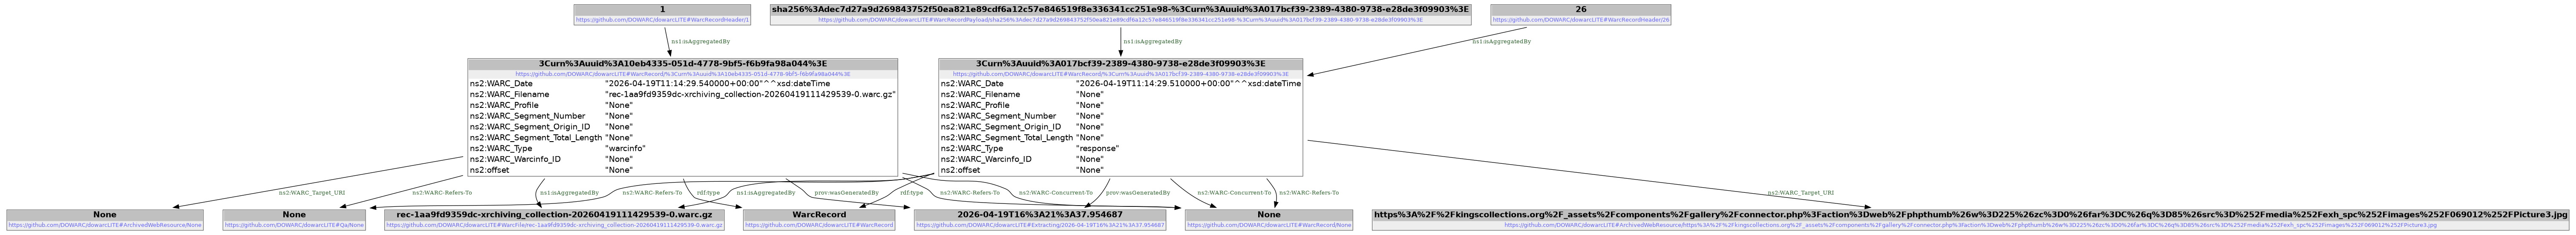

In [63]:
# Source - https://stackoverflow.com/a/61483971
# Posted by Christian Wartena
# License - CC BY-SA 4.0

import io
import pydotplus
from IPython.display import display, Image
from rdflib.tools.rdf2dot import rdf2dot
from rdflib import Graph, URIRef

g = Graph()
g.parse(output_file, format="turtle")

target_uri_1 = URIRef("https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A017bcf39-2389-4380-9738-e28de3f09903%3E")
target_uri_2 = URIRef("https://github.com/DOWARC/dowarcLITE#WarcRecord/%3Curn%3Auuid%3A10eb4335-051d-4778-9bf5-f6b9fa98a044%3E")

subgraph2 = Graph()
for target in [target_uri_1, target_uri_2]:
    for s, p, o in g.triples((target, None, None)):
        subgraph2.add((s, p, o))
    for s, p, o in g.triples((None, None, target)):
        subgraph2.add((s, p, o))

print(f"Created subgraph2 with {len(subgraph2)} triples")

def visualize(g, output_file="subgraph2.png"):
    stream = io.StringIO()
    rdf2dot(g, stream)
    dg = pydotplus.graph_from_dot_data(stream.getvalue())
    png = dg.create_png()
    display(Image(png))

    with open(output_file, "wb") as f:
        f.write(png)
     
visualize(subgraph2)

Visualize <code>subgraph2</code> with <code>matplotlib.pyplo</code> as a static graph, saved to file as <code>png</code>. Depending on available compute power, the <code>subgraph2</code> might be also displayed directly in the notebook.

In [64]:
!jupyter_env/bin/pip install matplotlib

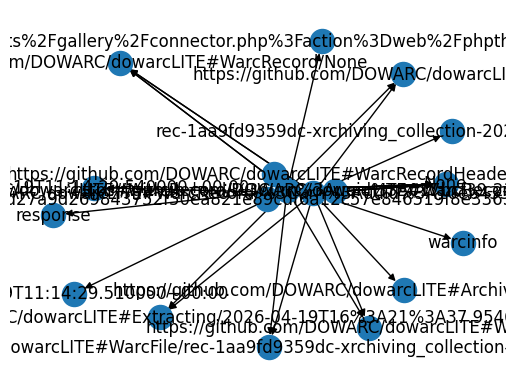

In [65]:
# Source - https://stackoverflow.com/a/54095269
# Posted by Tom Hemmes, modified by community. See post 'Timeline' for change history
# License - CC BY-SA 4.0

import rdflib
from rdflib.extras.external_graph_libs import rdflib_to_networkx_multidigraph
import networkx as nx
import matplotlib.pyplot as plt

G = rdflib_to_networkx_multidigraph(subgraph2)

# Plot Networkx instance of RDF Graph
pos = nx.spring_layout(G, scale=2)
edge_labels = nx.get_edge_attributes(G, 'r')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
nx.draw(G, with_labels=True)

# Save it as *.png file
plt.savefig("subgraph2b.png", dpi=300, bbox_inches="tight")

#if not in interactive mode for 
plt.show()